<div style="background:linear-gradient(135deg,#603813 0%,#b29f94 100%);padding:32px 34px;border-radius:16px;
            box-shadow:0 8px 24px rgba(0,0,0,0.18);font-family:'Segoe UI',Roboto,sans-serif;">
  <h1 style="margin:0;color:#ffffff;font-size:34px;letter-spacing:-0.5px;">⏱️&nbsp; Benchmark: Training Performance & Scaling</h1>
  <p style="margin:12px 0 0;color:#eaf6ff;font-size:17px;line-height:1.5;max-width:760px;">How does training cost scale with the number of collocation points and the network size? We measure throughput and use the library's profiling utilities to find the bottlenecks.</p>
</div>

<div><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">type</span><span style="background:#603813;color:#fff;padding:4px 8px;">benchmark</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">topic</span><span style="background:#1a73e8;color:#fff;padding:4px 8px;">profiling · scaling</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">runtime</span><span style="background:#7b3fe4;color:#fff;padding:4px 8px;">~1 min · CPU</span></span></div>

Knowing the **cost model** of your training loop tells you where to spend a bigger compute budget.
Here we vary the collocation count and the network width and record milliseconds per step.

<div style="background:#f6f8fa;border:1px solid #e1e4e8;border-radius:10px;padding:18px 24px;
            font-family:'Segoe UI',sans-serif;">
  <b style="font-size:15px;">📑 Table of Contents</b>
  <ol style="margin:10px 0 0;padding-left:20px;font-size:14px;line-height:1.6;">
  <li style="margin:3px 0;"><a href="#setup" style="color:#1a73e8;text-decoration:none;">1 · Setup</a></li>
  <li style="margin:3px 0;"><a href="#colloc" style="color:#1a73e8;text-decoration:none;">2 · Cost vs. Collocation Points</a></li>
  <li style="margin:3px 0;"><a href="#width" style="color:#1a73e8;text-decoration:none;">3 · Cost vs. Network Width</a></li>
  <li style="margin:3px 0;"><a href="#profile" style="color:#1a73e8;text-decoration:none;">4 · Profiling with the Library</a></li>
  <li style="margin:3px 0;"><a href="#takeaways" style="color:#1a73e8;text-decoration:none;">5 · Takeaways</a></li>
  </ol>
</div>

<a id="setup"></a>

## 1 · Setup

In [1]:
# --- Environment setup -------------------------------------------------------
import warnings, logging, os
warnings.filterwarnings("ignore")
logging.getLogger("pinn").setLevel(logging.ERROR)          # quiet library logs

# Disable tqdm progress bars for clean, static notebook output
from functools import partialmethod
import tqdm
tqdm.tqdm.__init__ = partialmethod(tqdm.tqdm.__init__, disable=True)

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl

# A clean, consistent "Kaggle" plotting theme ---------------------------------
plt.rcParams.update({
    "figure.figsize":   (9, 5),
    "figure.dpi":       110,
    "savefig.dpi":      110,
    "font.size":        11,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   11,
    "axes.edgecolor":   "#cccccc",
    "axes.grid":        True,
    "grid.color":       "#e6e6e6",
    "grid.linewidth":   0.8,
    "axes.axisbelow":   True,
    "legend.frameon":   True,
    "legend.framealpha":0.9,
})
ACCENT, ACCENT2, ACCENT3 = "#1a73e8", "#d6336c", "#1e9e54"

# Reproducibility -------------------------------------------------------------
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

import pinnkit
print(f"pinn version : {pinn.__version__}")
print(f"PyTorch      : {torch.__version__}")
print(f"Compute      : {DEVICE.upper()}")

pinn version : 0.1.0
PyTorch      : 2.11.0+cpu
Compute      : CPU


In [2]:
import time
from pinnkit.models import MLP
from pinnkit.solvers.raissi_improved import (
    BurgersConfig, TrainConfig, ContinuousPINN, burgers_residual)

cfg = BurgersConfig()
STEPS = 60                      # short timed bursts

def time_run(n_f, width):
    torch.manual_seed(SEED); np.random.seed(SEED)
    pinn = ContinuousPINN(MLP(2, 4, width, 1), DEVICE, burgers_residual, cfg)
    t0 = time.perf_counter()
    pinn.train(TrainConfig(n_u0=64, n_bc=64, n_f=n_f, adam_steps=STEPS,
                           lbfgs_max_iter=0, seed=SEED, track_losses=False))
    return (time.perf_counter() - t0) / STEPS * 1e3      # ms / step

<a id="colloc"></a>

## 2 · Cost vs. Collocation Points

Collocation points dominate PINN cost — each needs a forward pass plus second-order autograd.

n_f =   250 ->   45.8 ms/step
n_f =   500 ->   11.6 ms/step
n_f =  1000 ->   15.2 ms/step
n_f =  2000 ->   19.1 ms/step
n_f =  4000 ->   21.2 ms/step


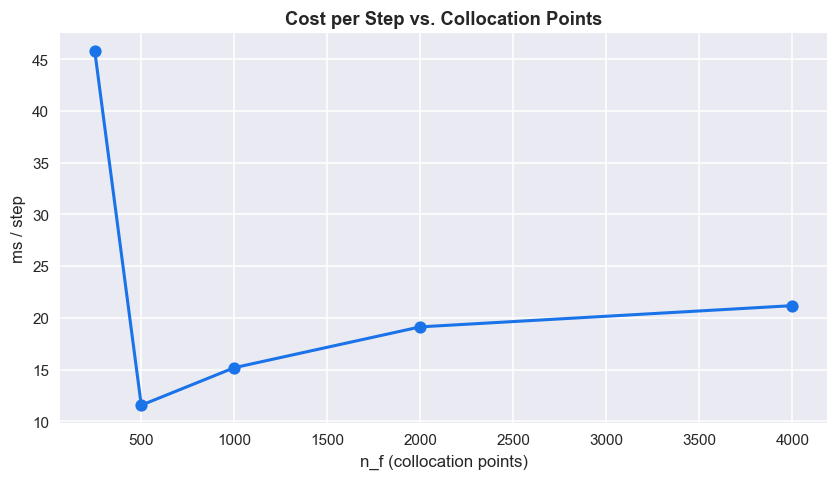

In [3]:
NFS = [250, 500, 1000, 2000, 4000]
ms_nf = [time_run(n, 32) for n in NFS]
for n, t in zip(NFS, ms_nf):
    print(f"n_f = {n:5d} -> {t:6.1f} ms/step")

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(NFS, ms_nf, "o-", color=ACCENT, lw=2, ms=8)
ax.set(title="Cost per Step vs. Collocation Points", xlabel="n_f (collocation points)",
       ylabel="ms / step"); ax.grid(True, which="both")
plt.show()

<a id="width"></a>

## 3 · Cost vs. Network Width

width =   16 ->    8.3 ms/step
width =   32 ->    9.4 ms/step
width =   64 ->   13.4 ms/step
width =  128 ->   25.3 ms/step


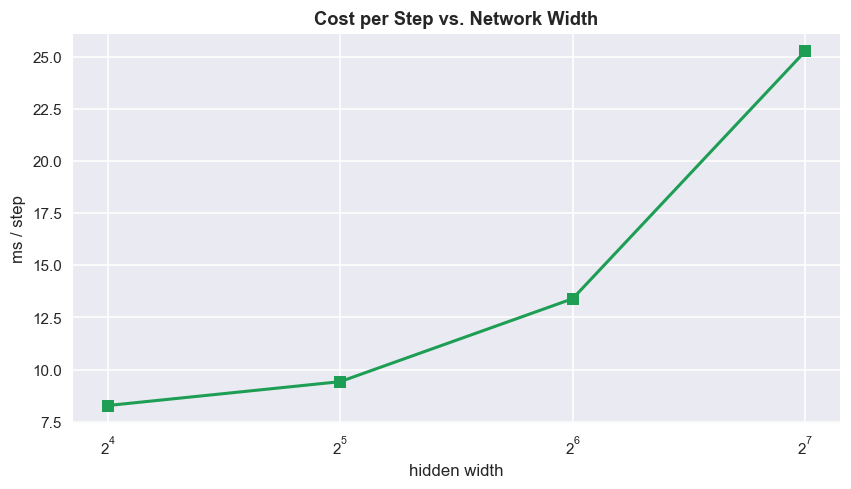

In [4]:
WIDTHS = [16, 32, 64, 128]
ms_w = [time_run(1000, w) for w in WIDTHS]
for w, t in zip(WIDTHS, ms_w):
    print(f"width = {w:4d} -> {t:6.1f} ms/step")

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(WIDTHS, ms_w, "s-", color=ACCENT3, lw=2, ms=8)
ax.set(title="Cost per Step vs. Network Width", xlabel="hidden width", ylabel="ms / step")
ax.set_xscale("log", base=2); plt.show()

<a id="profile"></a>

## 4 · Profiling with the Library

`PerformanceReport` + the `@profile_performance` decorator capture timing of any function — handy for finding hot spots in a custom loop.

In [5]:
from pinnkit.utils.profiling import PerformanceReport, profile_performance

report = PerformanceReport()

@profile_performance(report=report)
def one_training_burst():
    pinn = ContinuousPINN(MLP(2, 4, 32, 1), DEVICE, burgers_residual, cfg)
    pinn.train(TrainConfig(n_u0=64, n_bc=64, n_f=1000, adam_steps=40,
                           lbfgs_max_iter=0, seed=SEED, track_losses=False))

one_training_burst()
print("Captured timing records:")
for rec in report.records:
    print(" ", rec)

Captured timing records:
  PerformanceRecord(name='one_training_burst', duration_sec=0.27636049996363, cpu_mem_mb=0.0546875, gpu_mem_mb=None)


<div style="background:#e9f9ee;border-left:5px solid #1e9e54;border-radius:8px;
            padding:14px 18px;margin:6px 0;font-family:'Segoe UI',sans-serif;font-size:14px;line-height:1.6;">
  <b>✅ Tip.</b> Cost grows roughly linearly with collocation points and super-linearly with width — so when you need accuracy, adding collocation points is usually cheaper than widening the network.
</div>

<a id="takeaways"></a>

## 5 · Takeaways

- **Collocation count** is the primary cost driver and scales close to linearly.
- **Width** is cheaper to grow than collocation, until matrix multiplies dominate at large sizes.
- Use `PerformanceReport` / `@profile_performance` to profile your own loops before optimising.
- For real speed-ups on big problems, reach for mixed precision, gradient checkpointing
  (`TrainConfig` flags), and the [distributed trainer](../advanced/02_distributed_training.ipynb).

<div style="background:#0d1117;border-radius:12px;padding:22px 26px;color:#c9d1d9;
            font-family:'Segoe UI',sans-serif;font-size:13px;line-height:1.6;">
  <b style="color:#fff;font-size:15px;">Thanks for reading! 🙌</b><br>
  This notebook is part of the <code>pinn</code> example gallery. Explore the companion notebooks in
  <code>notebooks/basic</code>, <code>notebooks/advanced</code>, and <code>notebooks/benchmarks</code>
  for more physics-informed deep-learning recipes.
</div>